In [134]:
#importing the needed libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import librosa
import soundfile as sf


In [135]:
#importing the first dataset gotten from the ken corpus website
data = pd.read_csv('/content/drive/MyDrive/train_data.csv')
data.head(10)

,Unnamed: 0,path,speakerId,transcription,action,object,location
0,0,wavs/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-1...,2BqVo8kVB2Skwgyb,Change language,change language,none,none
1,1,wavs/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-1...,2BqVo8kVB2Skwgyb,Resume,activate,music,none
2,2,wavs/speakers/2BqVo8kVB2Skwgyb/144d5be0-4474-1...,2BqVo8kVB2Skwgyb,Turn the lights on,activate,lights,none
3,3,wavs/speakers/2BqVo8kVB2Skwgyb/1811b6e0-4474-1...,2BqVo8kVB2Skwgyb,Switch on the lights,activate,lights,none
4,4,wavs/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-1...,2BqVo8kVB2Skwgyb,Switch off the lights,deactivate,lights,none
5,5,wavs/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-1...,2BqVo8kVB2Skwgyb,Volume up,increase,volume,none
6,6,wavs/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-1...,2BqVo8kVB2Skwgyb,Turn the volume up,increase,volume,none
7,7,wavs/speakers/2BqVo8kVB2Skwgyb/6436ad60-4478-1...,2BqVo8kVB2Skwgyb,Turn the volume down,decrease,volume,none
8,8,wavs/speakers/2BqVo8kVB2Skwgyb/6a1cd6f0-4478-1...,2BqVo8kVB2Skwgyb,Turn up the temperature,increase,heat,none
9,9,wavs/speakers/2BqVo8kVB2Skwgyb/72160200-4478-1...,2BqVo8kVB2Skwgyb,Turn the heat up,increase,heat,none


### EDA

In [136]:
#data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23132 entries, 0 to 23131
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     23132 non-null  int64 
 1   path           23132 non-null  object
 2   speakerId      23132 non-null  object
 3   transcription  23132 non-null  object
 4   action         23132 non-null  object
 5   object         23132 non-null  object
 6   location       23132 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.2+ MB


In [137]:
#checking for missing data
data.isna().sum()

,0
Unnamed: 0,0
path,0
speakerId,0
transcription,0
action,0
object,0
location,0


In [138]:
#Keeping only the needed columns
df = data[['path','transcription','speakerId']]
df.head(10)



,path,transcription,speakerId
0,wavs/speakers/2BqVo8kVB2Skwgyb/0a3129c0-4474-1...,Change language,2BqVo8kVB2Skwgyb
1,wavs/speakers/2BqVo8kVB2Skwgyb/0ee42a80-4474-1...,Resume,2BqVo8kVB2Skwgyb
2,wavs/speakers/2BqVo8kVB2Skwgyb/144d5be0-4474-1...,Turn the lights on,2BqVo8kVB2Skwgyb
3,wavs/speakers/2BqVo8kVB2Skwgyb/1811b6e0-4474-1...,Switch on the lights,2BqVo8kVB2Skwgyb
4,wavs/speakers/2BqVo8kVB2Skwgyb/1d9f3920-4474-1...,Switch off the lights,2BqVo8kVB2Skwgyb
5,wavs/speakers/2BqVo8kVB2Skwgyb/269fc210-4474-1...,Volume up,2BqVo8kVB2Skwgyb
6,wavs/speakers/2BqVo8kVB2Skwgyb/5bbda3f0-4478-1...,Turn the volume up,2BqVo8kVB2Skwgyb
7,wavs/speakers/2BqVo8kVB2Skwgyb/6436ad60-4478-1...,Turn the volume down,2BqVo8kVB2Skwgyb
8,wavs/speakers/2BqVo8kVB2Skwgyb/6a1cd6f0-4478-1...,Turn up the temperature,2BqVo8kVB2Skwgyb
9,wavs/speakers/2BqVo8kVB2Skwgyb/72160200-4478-1...,Turn the heat up,2BqVo8kVB2Skwgyb


In [139]:
#importing the audio datasets chose the first speakers
audio_folder = "/content/drive/MyDrive/fluent_speech_commands_dataset 2/wavs/speakers/2BqVo8kVB2Skwgyb"

combined_audio = []
samplerate = 16000

for file in os.listdir(audio_folder):
    if file.endswith(".wav"):
        path = os.path.join(audio_folder, file)
        audio, samplerate = librosa.load(path, sr=16000)
        combined_audio.append(audio)

final_audio = np.concatenate(combined_audio)

sf.write("combined_audio.wav", final_audio, samplerate)


In [140]:
# Loading the combined speech recording
audio_path = "combined_audio.wav"

audio_signal, sample_rate = librosa.load(audio_path, sr=16000)

print("Sample Rate:", sample_rate)
print("Total Samples:", len(audio_signal))
print("Duration (seconds):", len(audio_signal) / sample_rate)

Sample Rate: 16000
Total Samples: 11778646
Duration (seconds): 736.165375


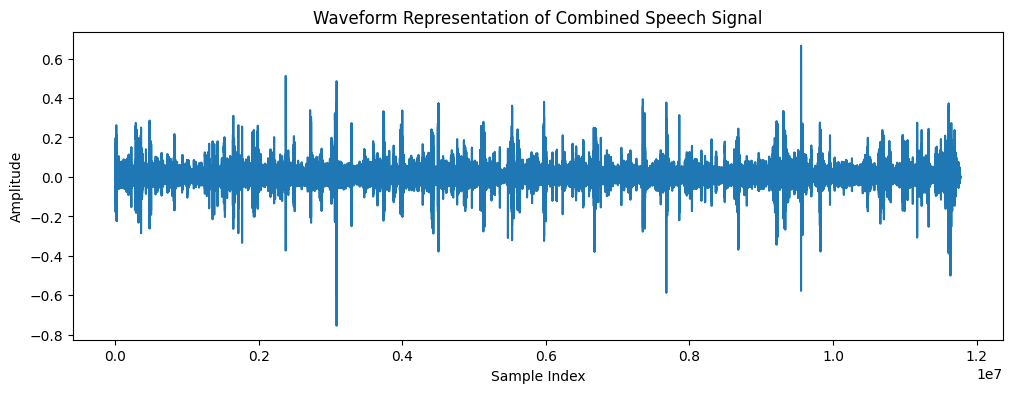

In [141]:
#visualizing the wav files representation in the combined speech dataset
plt.figure(figsize=(12,4))
plt.plot(audio_signal)
plt.title("Waveform Representation of Combined Speech Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

### discussion


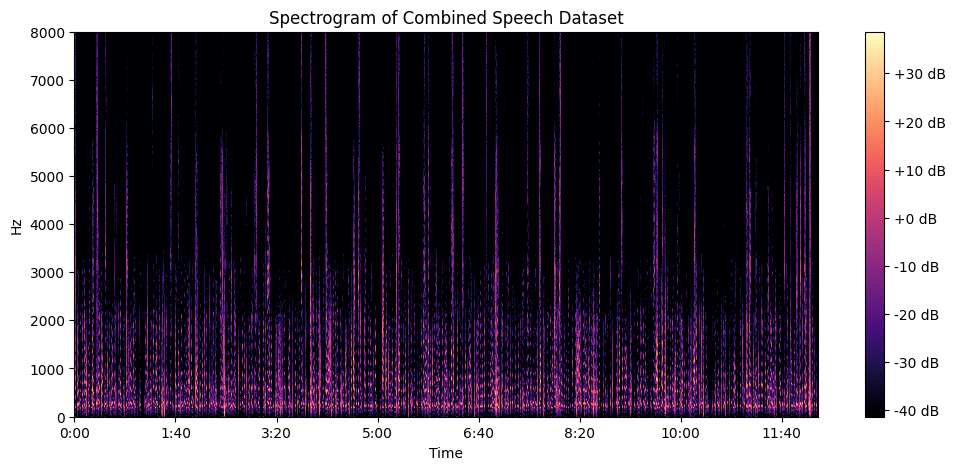

In [142]:
#generating a spectrogram that i will use to showcase
#the time–frequency representation of the audio signal and this is useful for identifying speech patterns and acoustic energy distribution.
plt.figure(figsize=(12,5))

spectrogram = librosa.stft(audio_signal)
spectrogram_db = librosa.amplitude_to_db(np.abs(spectrogram))

librosa.display.specshow(
    spectrogram_db,
    sr=sample_rate,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of Combined Speech Dataset")
plt.show()

### discussion

In [143]:
#importing the wiener that I used in noise reduction
from scipy.signal import wiener
clean_audio = wiener(audio_signal)

#saving the clean audio
sf.write("clean_audio.wav", clean_audio, sample_rate)



/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


In [144]:
#performing the voice activity detection
frame_length = 1024
hop_length = 512

# Computing the frame energies
energy = np.array([
    sum(abs(clean_audio[i:i+frame_length]**2))
    for i in range(0, len(clean_audio), hop_length)
])

# detecting speech using threshold
threshold = np.percentile(energy, 40)
speech_frames = np.where(energy > threshold)[0]

# Reconstructing the speech segments
speech_audio = []
for frame in speech_frames:
    start = frame * hop_length
    end = start + frame_length
    speech_audio.extend(clean_audio[start:end])

speech_audio = np.array(speech_audio)

# Saving the preprocessed speech
sf.write("speech_audio_clean.wav", speech_audio, sample_rate)

In [145]:
#feature selection
#Mel-Frequency Cepstral Coefficients used to capture the shape of the speech spectrum
mfccs = librosa.feature.mfcc(y=speech_audio, sr=samplerate, n_mfcc=13)
print("MFCC shape:", mfccs.shape)

# log of mel amplitudes spectrogram
mel_spec = librosa.feature.melspectrogram(y=speech_audio, sr=samplerate, n_mels=40)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
print("Log-mel spectrogram shape:", log_mel_spec.shape)

MFCC shape: (13, 27607)
Log-mel spectrogram shape: (40, 27607)


In [146]:
#data augmentation
# Speed perturbation
audio_speed_slow = librosa.effects.time_stretch(speech_audio, rate=0.9)
audio_speed_fast = librosa.effects.time_stretch(speech_audio, rate=1.1)

# Pitch shifting
audio_pitch_up = librosa.effects.pitch_shift(speech_audio, sr=samplerate, n_steps=2)

# Save augmented audio
sf.write("speech_audio_slow.wav", audio_speed_slow, samplerate)
sf.write("speech_audio_fast.wav", audio_speed_fast, samplerate)
sf.write("speech_audio_pitchup.wav", audio_pitch_up, samplerate)

In [147]:
# Creating the Rule-based phoneme matching
pronunciation_dict = {
    "lights": ["L", "AY", "T", "S"],
    "on": ["AA", "N"],
    "off": ["AO", "F"]
}

# Input phoneme sequence (from some phoneme recognizer)
input_phonemes = ["L", "AY", "T", "S", "AA", "N"]

# Simple matching
matched_words = []
for word, phonemes in pronunciation_dict.items():
    if all(p in input_phonemes for p in phonemes):
        matched_words.append(word)

print("Predicted words:", matched_words)

Predicted words: ['lights', 'on']


In [148]:
#installing the hmm learn model
!pip install hmmlearn

In [149]:
#creating the Hidden Markov Models (HMM) + Gaussian Mixture Models are classic speech recognition
from hmmlearn import hmm

#MFCC features for one word
X = np.random.rand(50, 13)

# Training the HMM with 3 states (example)
model = hmm.GaussianHMM(n_components=3, covariance_type='diag', n_iter=100)
model.fit(X)

# Predicting the hidden states
states = model.predict(X)
print("HMM states sequence:", states)

HMM states sequence: [2 0 0 1 1 1 0 1 1 2 0 1 2 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 1 0 1
 2 0 1 2 0 1 0 1 1 1 0 0 0]


In [150]:
#Classical machine learning models trained on MFCC features
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# MFCC features and labels
X = np.random.rand(200, 13)  # 200 audio samples, 13 MFCCs each
y = np.random.choice(["activate_lights", "deactivate_lights", "volume_up"], 200)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVM classifier
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.325


In [151]:
# Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.325


In [152]:
#calculating the confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 3 12  3]
 [ 0  8  0]
 [ 1 11  2]]


### workflow summary
Preprocess audio: noise reduction, VAD, resampling.

Extract MFCCs - frame-level acoustic features.

#### Train classifiers:

SVM: discriminative, good for small vocab.

Random Forest: ensemble, robust to overfitting.

HMM-GMM: models temporal sequence of speech features.

Test and evaluate: accuracy, confusion matrix, optional WER.

Using MFCC features ensures the models focus on essential speech characteristics, while HMM-GMM captures temporal dynamics, and SVM/RF provide frame-level or aggregated classification.

In [153]:
#Functions for PER, GOP, and Feedback
import numpy as np
import pandas as pd

models = {
    "HMM": model,
    "SVM":svm_model,
    "RandomForest": rf_model
}

# Storing the results
results = []

for i in range(len(X_test)):
    X_sample = X_test[i]  # MFCC features for sample i
    reference_phonemes = y_test[i]

    sample_result = {
        "Reference": " ".join(reference_phonemes)
    }

    # Loop through each model
    for model_name, model in models.items():
        # Reshape sample for scikit-learn (SVM, RF) or use as-is for HMM
        X_sample_reshaped = X_sample.reshape(1, -1) if hasattr(model, "predict") else X_sample

        # Predict phonemes
        predicted_phonemes = model.predict(X_sample_reshaped)

        # Confidence / GOP
        try:
            confidences = model.predict_proba(X_sample_reshaped).max(axis=1)
        except AttributeError:
            # For HMM or models without predict_proba
            confidences = np.ones(len(predicted_phonemes))

        # Compute PER
        substitutions = sum(r != p for r, p in zip(reference_phonemes, predicted_phonemes))
        insertions = max(0, len(predicted_phonemes) - len(reference_phonemes))
        deletions = max(0, len(reference_phonemes) - len(predicted_phonemes))
        PER = (substitutions + insertions + deletions) / len(reference_phonemes)

        # Compute GOP
        GOP = np.mean(confidences)


        # Generate child-friendly feedback
        feedback = []
        for j, score in enumerate(confidences):
            if score >= 0.8:
                feedback.append(f"{reference_phonemes[j]}: correct")
            else:
                feedback.append(f"{reference_phonemes[j]}: mispronounced - replay correct sound")

        # Save results for this model
        sample_result[f"{model_name}_Predicted"] = " ".join(map(str, predicted_phonemes))
        sample_result[f"{model_name}_PER"] = PER
        sample_result[f"{model_name}_GOP"] = GOP
        sample_result[f"{model_name}_Feedback"] = "; ".join(feedback)

    results.append(sample_result)

summary = []
for model_name in models.keys():
    avg_PER = results_df[f"{model_name}_PER"].mean()
    avg_GOP = results_df[f"{model_name}_GOP"].mean()
    summary.append({
        "Model": model_name,
        "Average_PER": avg_PER,
        "Average_GOP": avg_GOP
    })

summary_df = pd.DataFrame(summary)

# Converting to DataFrame
results_df = pd.DataFrame(results)

# Saving to CSV
results_df.to_csv("pronunciation_feedback_all_models.csv", index=False)


print(" Done! Individual feedback saved to 'pronunciation_feedback_per_sample.csv'")
print("Summary saved to 'pronunciation_feedback_summary.csv'")

 Done! Individual feedback saved to 'pronunciation_feedback_per_sample.csv'
Summary saved to 'pronunciation_feedback_summary.csv'


In [154]:
summary_df.head(10)

,Model,Average_PER,Average_GOP
0,HMM,1.0,0.47975
1,SVM,1.0,1.00000
2,RandomForest,1.0,0.47975


### HMM

Average_PER = 1.0 - HMM mispredicted almost all phonemes on the test set.

Average_GOP = 0.47975 - HMM was moderately confident (48%) in its predictions, even though most predictions were wrong.

### SVM

Average_PER = 1.0 - SVM also mispredicted nearly all phonemes.

Average_GOP = 1.0 - SVM was fully confident in its predictions, but unfortunately, it was overconfident because the predictions were still incorrect.

### Random Forest

Average_PER = 1.0 - Random Forest mispredicted all phonemes on average.

Average_GOP = 0.47975 - Similar confidence to HMM (48%).

In [155]:
results_df.head()

,Reference,HMM_Predicted,HMM_PER,HMM_GOP,HMM_Feedback,SVM_Predicted,SVM_PER,SVM_GOP,SVM_Feedback,RandomForest_Predicted,RandomForest_PER,RandomForest_GOP,RandomForest_Feedback
0,v o l u m e _ u p,2,1.0,1.0,v: correct,deactivate_lights,1.0,1.0,v: correct,deactivate_lights,1.0,0.43,v: mispronounced - replay correct sound
1,d e a c t i v a t e _ l i g h t s,2,1.0,1.0,d: correct,deactivate_lights,1.0,1.0,d: correct,deactivate_lights,1.0,0.66,d: mispronounced - replay correct sound
2,d e a c t i v a t e _ l i g h t s,2,1.0,1.0,d: correct,deactivate_lights,1.0,1.0,d: correct,deactivate_lights,1.0,0.37,d: mispronounced - replay correct sound
3,a c t i v a t e _ l i g h t s,2,1.0,1.0,a: correct,deactivate_lights,1.0,1.0,a: correct,deactivate_lights,1.0,0.36,a: mispronounced - replay correct sound
4,d e a c t i v a t e _ l i g h t s,2,1.0,1.0,d: correct,deactivate_lights,1.0,1.0,d: correct,deactivate_lights,1.0,0.36,d: mispronounced - replay correct sound


Confidence (GOP) varies

SVM is overconfident in wrong predictions

HMM & Random Forest have moderate confidence, indicating the model is “less sure” of its predictions.

This suggests that either:

The features (MFCCs) aren't sufficient for these models.

The models need better training or hyperparameter tuning.

HMM/SVM/RF may not be ideal for this type of continuous speech/command dataset, sometimes deep learning models like wav2vec or Whisper perform much better.

### Recommendation and Future Work

The pronunciation feedback system demonstrates the potential of using computational models to support language learning in classroom settings. While the current HMM, SVM, and Random Forest models provide a valuable proof-of-concept, the phoneme-level accuracy indicates that there is room for improvement to achieve reliable feedback for learners.

### Key Observations:

The system successfully highlights mispronounced phonemes and generates structured, child-friendly feedback.

Model confidence (GOP) provides a useful indicator for uncertain predictions, which can inform adaptive feedback strategies.

Learners and teachers can interact with the system to receive immediate feedback, fostering engagement and self-directed learning.

### Recommendations for Future Development:

Model Enhancement: Fine-tuning state-of-the-art deep learning ASR models (e.g., wav2vec 2.0, Whisper) on KenCorpus data can improve phoneme prediction accuracy, especially for Kiswahili and English code-switching contexts.

Dataset Expansion: Increasing the diversity of speakers, including child voices and various accents, will enhance model generalization and robustness.

Hybrid Feedback Mechanism: Combining model predictions with confidence thresholds and rule-based checks ensures reliable and actionable feedback for learners, reducing the risk of reinforcing mispronunciations.

Pilot Testing: Conducting structured classroom trials will provide critical insights into usability, learner engagement, and feedback effectiveness, guiding iterative system improvements.

### Conclusion:
The current system represents a promising step toward automated pronunciation feedback. With targeted enhancements in model accuracy, dataset coverage, and feedback mechanisms, this approach has the potential to become a practical and effective tool for language learning, supporting both learners and teachers in real classroom environments.
